# Step 3: Exploratory Data Analysis

Research questions:
1. How have terrorism trends shifted over time by ideology?
2. Which regions are most affected, and by which ideologies?
3. What are the deadliest attack types?
4. Does ideology correlate with target selection?
5. How does suicide attack usage vary across ideologies?

In [8]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv('../data/processed/gtd_processed.csv', low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

IDEOLOGY_COLORS = {
    'Religious Extremist': '#e74c3c',
    'Ethno-Nationalist':   '#3498db',
    'Left-Wing':           '#e67e22',
    'Right-Wing':          '#9b59b6',
    'Single Issue':        '#2ecc71',
    'Unknown':             '#95a5a6',
}

Loaded: 181,691 rows x 23 columns


## 3.1 Ideology over time (stacked area)

In [9]:
pivot = df.groupby(['year','ideology']).size().unstack(fill_value=0).reset_index()
fig = px.area(
    pivot.melt(id_vars='year', var_name='ideology', value_name='incidents'),
    x='year', y='incidents', color='ideology',
    color_discrete_map=IDEOLOGY_COLORS,
    title='Incidents by ideology 1970-2020'
)
fig.update_layout(hovermode='x unified', template='plotly_dark')
fig.show()
print('KEY: 2011-2015 spike = ISIL expansion + Boko Haram escalation (geopolitical, not eternal trend)')

KEY: 2011-2015 spike = ISIL expansion + Boko Haram escalation (geopolitical, not eternal trend)


## 3.2 Ideology vs Region heatmap (% share)

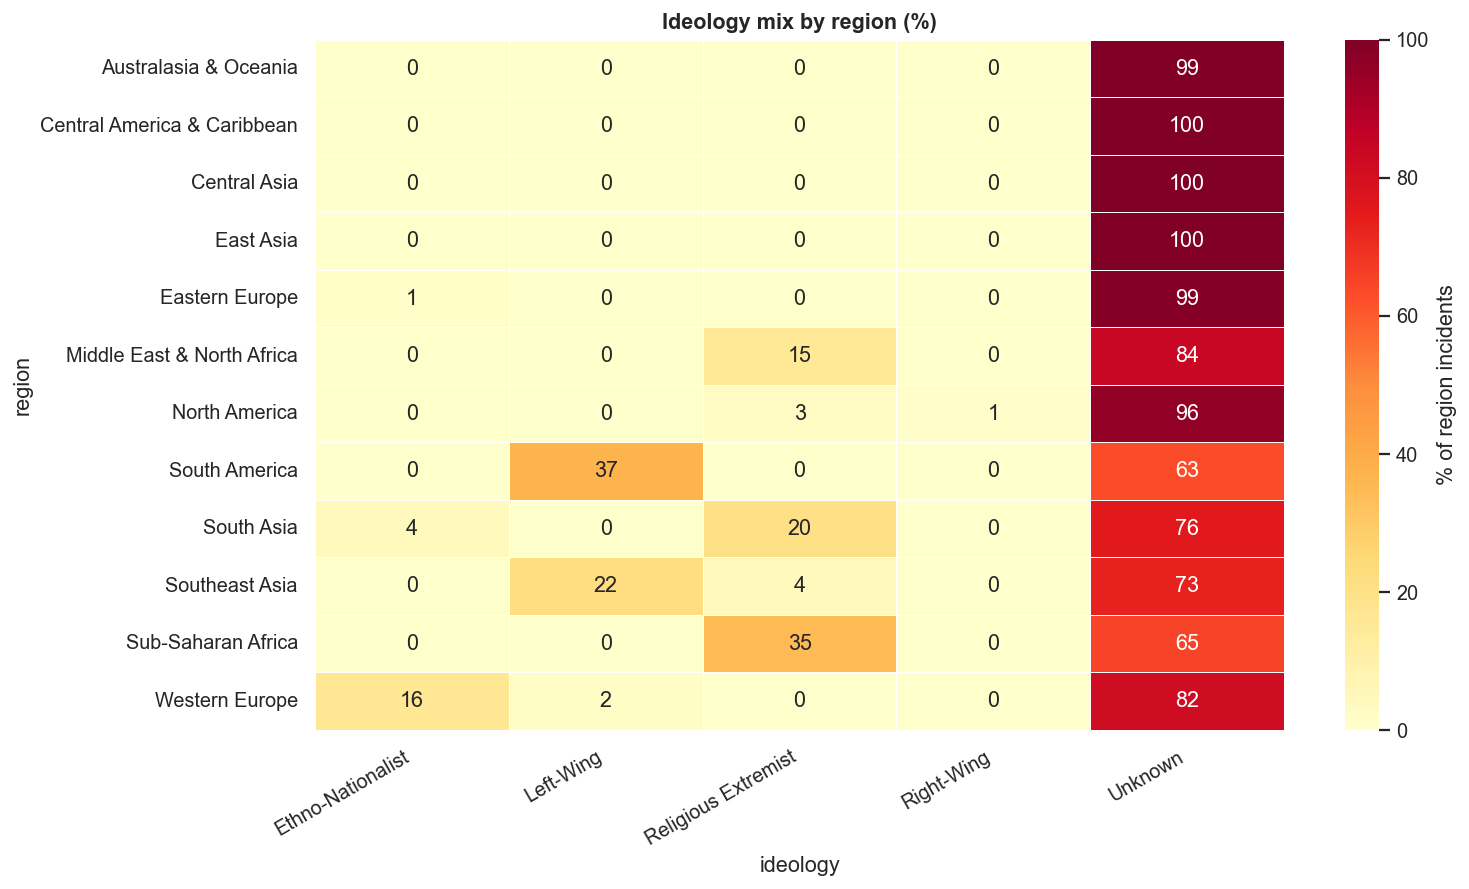

In [10]:
region_col = 'region' if 'region' in df.columns else 'region_txt'
hm = df.groupby([region_col,'ideology']).size().unstack(fill_value=0)
hm_pct = hm.div(hm.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(12,7))
sns.heatmap(hm_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of region incidents'})
ax.set_title('Ideology mix by region (%)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/eda_heatmap.png', dpi=150)
plt.show()

## 3.3 Casualties by ideology (box plot)

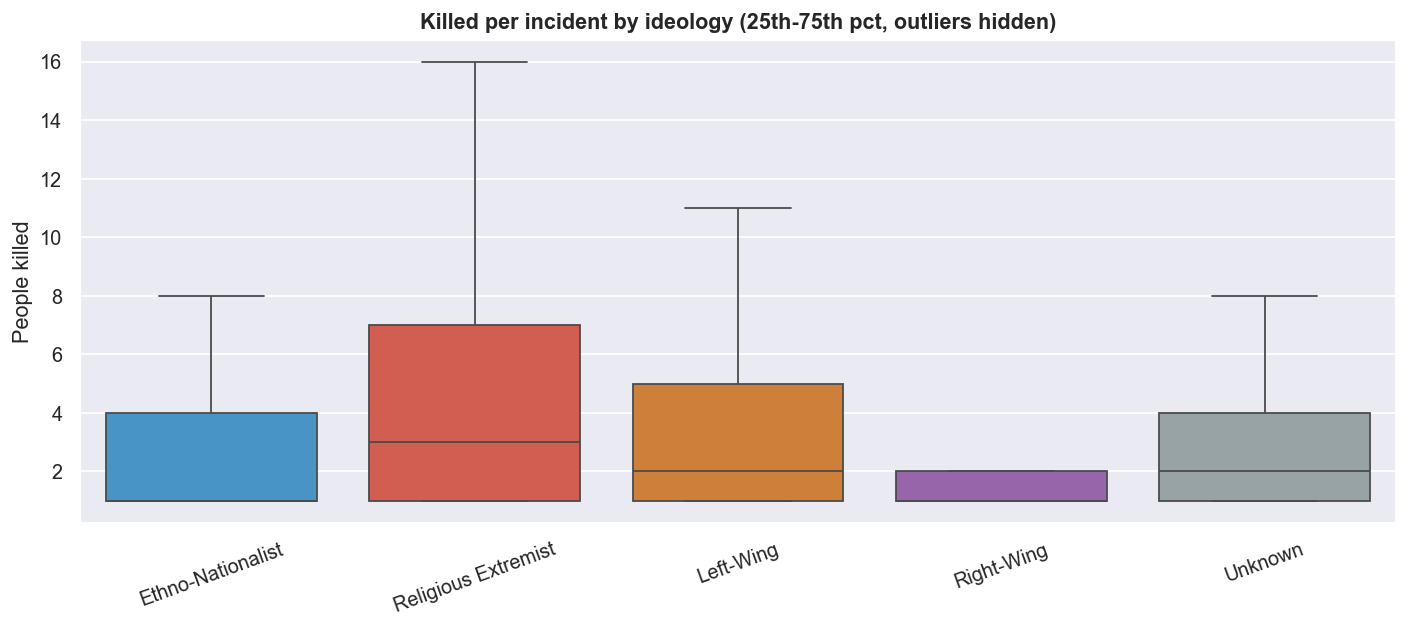

In [11]:
kill_col = 'killed' if 'killed' in df.columns else 'nkill'
nonzero = df[df[kill_col] > 0]
order = df.groupby('ideology')[kill_col].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11,5))
sns.boxplot(data=nonzero, x='ideology', y=kill_col, order=order,
            palette=IDEOLOGY_COLORS, showfliers=False, ax=ax)
ax.set_title('Killed per incident by ideology (25th-75th pct, outliers hidden)', fontweight='bold')
ax.set_ylabel('People killed'); ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../data/processed/eda_casualties.png', dpi=150)
plt.show()

## 3.4 Era analysis — ideology shift over decades

IndexError: index 0 is out of bounds for axis 0 with size 0

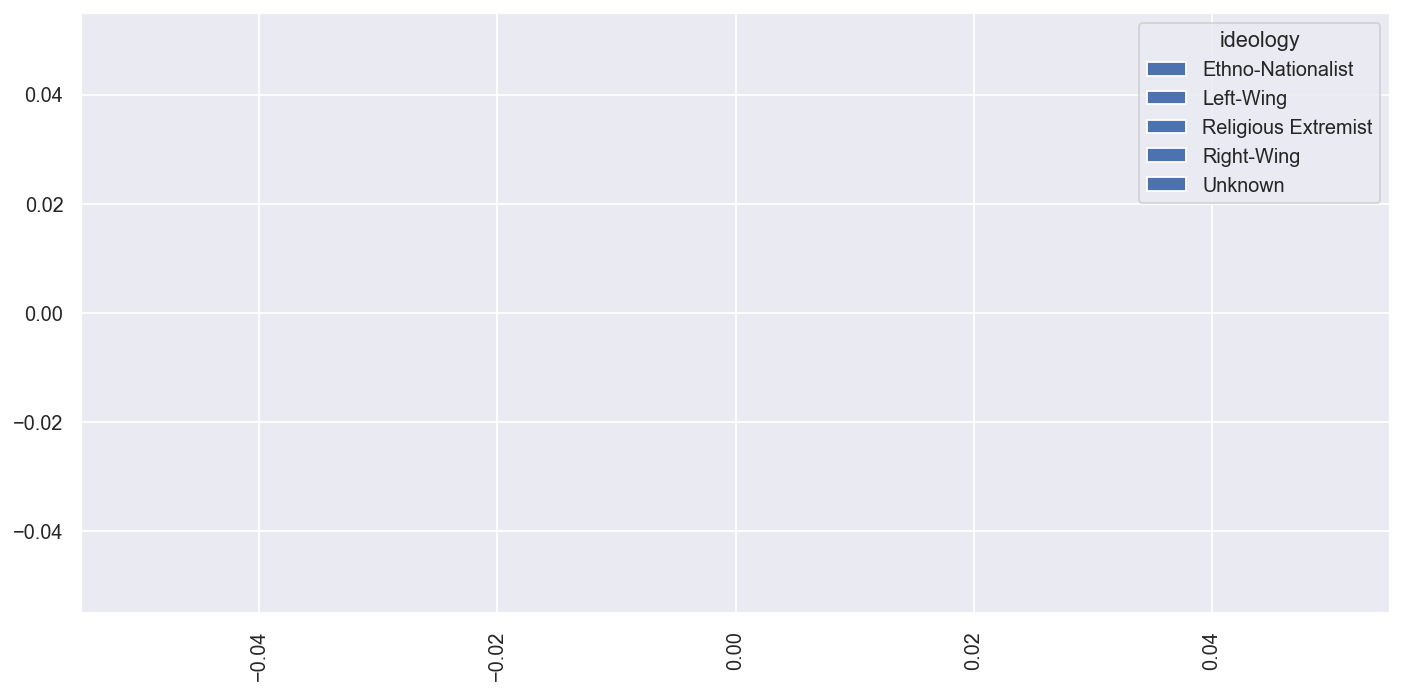

In [14]:
if 'era' in df.columns:
    era_pct = (df.groupby(['era','ideology']).size().unstack(fill_value=0)
               .apply(lambda x: x/x.sum()*100, axis=1))
    era_order = ['Cold War (1970-79)','Cold War (1980-89)','Post-Cold War (1990-2000)',
                 'Post-9/11 (2001-09)','ISIS Rise (2010-14)','Recent (2015+)']
    era_pct = era_pct.reindex([e for e in era_order if e in era_pct.index])
    ax = era_pct.plot(kind='bar', stacked=True, figsize=(13,6),
                      color=[IDEOLOGY_COLORS.get(c,'#bdc3c7') for c in era_pct.columns])
    ax.set_title('Ideology share by historical era (%)', fontweight='bold')
    ax.set_ylabel('%'); ax.set_xlabel('')
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    plt.xticks(rotation=25); plt.tight_layout()
    plt.savefig('../data/processed/eda_era.png', dpi=150)
    plt.show()
    print('Cold War 1970-89: Left-Wing + Ethno-Nationalist dominated')
    print('Post-2001: Religious Extremist share grew sharply')
    print('Post-2015: Right-Wing share rising in Western countries')

## 3.5 Summary stats table

In [13]:
kill_col = 'killed' if 'killed' in df.columns else 'nkill'
summary = df.groupby('ideology').agg(
    incidents=('ideology','count'),
    total_killed=(kill_col,'sum'),
    avg_killed=(kill_col,'mean'),
    median_killed=(kill_col,'median')
).round(2).sort_values('incidents', ascending=False)
print(summary.to_string())
print('\nNext -> notebooks/05_clustering.ipynb')

                     incidents  total_killed  avg_killed  median_killed
ideology                                                               
Unknown                 143132        256570        1.79            0.0
Religious Extremist      23676        119714        5.06            1.0
Left-Wing                10165         22142        2.18            0.0
Ethno-Nationalist         4691         13434        2.86            1.0
Right-Wing                  27             8        0.30            0.0

Next -> notebooks/05_clustering.ipynb
